In [1]:
#Imports
import torch 
from torch import nn
import random
import sys, os
from numpy import genfromtxt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from lib.tools import random_ranges
import numpy as np
from lib.pinn_auxloss_f import Pinn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import jax.numpy as jnp
import pandas as pd
from bioprocess_utils import *
from sklearn.metrics import r2_score
import matplotlib.colors as mcolors


In [2]:
#Specifying the seed
random.seed(42) #42
torch.manual_seed(42) #42

In [3]:
# observables and inputs paths to load
csv_path         = "./simulated_dataset/pputida_fedbatch_v1.wide.csv"
inputs_path      =  "./inputs/inputs.json"
inputs           = load_model_inputs(inputs_path)
df, meta         = load_synthetic_dataset(csv_path)
pinn_output_path = "./outputs/pinn/"

In [4]:
# observables and variables
observables     = ["Biomass", "Sub"]
data_t          = np.unique(df["time"])
variables_data  = {obs_i:np.array([np.mean([df[obs_i][it+len(data_t)*iexp] for iexp in np.unique(df["experiment"])]) for it in range(0,len(data_t))]) for obs_i in observables}
all_variables   = list(inputs["initials"].keys())
non_observables = list(filter(lambda x: x not in observables, all_variables))

# parameters inputs and ranges
prm_to_infer      = ["mu_max","K_subs","K_L_a"]
scale_prm_bound   = 100.0 
prm_to_infer_val  = [inputs["params"][prm_i]["values"][0] for prm_i in prm_to_infer]
ranges            = [(prm_to_infer_val[iprm]/scale_prm_bound,prm_to_infer_val[iprm]*scale_prm_bound)for iprm in range(0,len(prm_to_infer))]
variables_no_data = {var_i:None for var_i in non_observables}
all_prm_str       = list(inputs["params"].keys())
all_prm_val_dict  = {prm_i: inputs["params"][prm_i]["values"][0] for prm_i in all_prm_str}
#--------------------------------------------------------------------------
# building up the auxiliary dataset
# 1) Normalization stats for observables (PINN does the same internally)
obs_min = {k: float(np.min(variables_data[k])) for k in observables}
obs_max = {k: float(np.max(variables_data[k])) for k in observables}

def norm_obs(k, v):
    return (v - obs_min[k]) / (obs_max[k] - obs_min[k] + 1e-12)

# 2) Forward sim to get last-time values for all states
# Make sure the sim evaluates exactly at your data_t to align indices.
params      = inputs["params"]
initials    = inputs["initials"]
[inputs["initials"][obs]["values"].__setitem__(0, variables_data[obs][0]) for obs in observables] # updating the initials states from the avaible observable data
mode_name   = inputs.get("mode_name", "fed-batch")
mode_consts = inputs.get("mode_consts", {})
t_span      = (float(data_t[0]), float(data_t[-1]))

sol = run_model(params=params, initials=initials,
                mode_name=mode_name, mode_consts=mode_consts,
                t_span=t_span, t_eval=data_t)   # attaches sol.state_names
name2idx = {name: i for i, name in enumerate(sol.state_names)}  # provided by the runner

# 3) Build the two snapshots in the network's space
aux_t0 = []
aux_t1 = []

# Observables: normalized to match net_output space
for k in observables:
    v0 = float(variables_data[k][0])
    v1 = float(variables_data[k][-1])
    aux_t0.append(norm_obs(k, v0))
    aux_t1.append(norm_obs(k, v1))

# Non-observables: raw units (no normalization in PINN for these)
for k in non_observables:
    v0 = float(initials[k]["values"][0])                 # t0 from inputs
    v1 = float(sol.y[name2idx[k], -1])                   # t_end from forward sim
    aux_t0.append(v0)
    aux_t1.append(v1)

# 4) Torch tensor with shape (2, nb_variables)
data_aux = torch.stack([
    torch.tensor(aux_t0, dtype=torch.float32),
    torch.tensor(aux_t1, dtype=torch.float32)
])

#--------------------------------------------------------------------------
# refining inputs format
Vf0      = float(mode_consts.get("Vf_const", 0.0))
Vs0      = float(mode_consts.get("Vs_const", 0.0))
VGasIn0  = float(mode_consts.get("VGasIn_const", 0.0))
VOffGas0 = float(mode_consts.get("VOffGas_const", Vs0 + Vf0 + inputs["params"]["V_g"]["values"][0]))
Va0      = float(mode_consts.get("Va_const", 0.0))
Vb0      = float(mode_consts.get("Vb_const", 0.0))

flows = {"Vf": Vf0, "Vs": Vs0, "VGasIn": VGasIn0, "VOffGas": VOffGas0, "Va": Va0, "Vb": Vb0}

constants_dict = all_prm_val_dict | flows

In [15]:
#--------------------------------------------------------------------------
# hyperparameters
epoch_number = 8400

# Optimizer parameters
optimizer_type = "Adam"
optimizer_hyperparameters = {"lr":1e-4, "betas":(0.9, 0.8)} # def: {"lr":1e-4, "betas":(0.9, 0.8)}

# Scheduler parameters
scheduler_hyperparameters = {"base_lr":1e-4,
                             "max_lr":1e-4,
                             "step_size_up":100,
                             "scale_mode":"exp_range",
                             "gamma":0.999,
                             "cycle_momentum":False}

#Specifying the guiding weighting of the PINN (i.e. the weights that will multiply the balancing method output)
residual_weights = [10**-1 if x in observables else 10**-8 for x in all_variables] # def: observables: 10**-1, all_variables 10**-8
# Loss balancing method
multiple_loss_method = "prior_losses"

In [16]:
#Creating PINN
pinn_cell = Pinn(ode_residual_dict=ODE_residual_dict_Bioprocess, # ode structure for the PINN
                 ranges=ranges, # intervals
                 data_t=data_t, # time ticks
                 variables_data=variables_data, # observables
                 variables_no_data=variables_no_data,# non-observables (-> non-available so set to None to each variable)
                 data_aux=data_aux, # auxilliary data: first value and last value for each data
                 parameter_names=prm_to_infer, # ok
                 optimizer_type=optimizer_type, # ok
                 optimizer_hyperparameters=optimizer_hyperparameters, # ok
                 scheduler_hyperparameters=scheduler_hyperparameters, # ok
                 constants_dict=constants_dict, # ok
                 #Loss balancing specification
                 multi_loss_method=multiple_loss_method, # ok
                 residual_weights=residual_weights, # ok
                 variable_fit_weights=None,
                 auxiliary_fit_weights=None,
                 #SoftAdapt parameters
                 soft_adapt_beta=0.1,
                 soft_adapt_t=1,
                 soft_adapt_normalize=True,
                 soft_adapt_by_type=True,
                 soft_adapt_eps=10E-8,
                 soft_adapt_warming=-1,
                 #Increments parametrisation
                 incr_residual_weight=20000,
                 increment=1E2,
                 #Prior_losses parameters
                 prior_losses_t=100,
                 #Wang parameters
                 wang_residual = True,
                 wang_t=1,
                 wang_alpha=0.9,
                 wang_epsilon=1E-8,
                 wang_warming=-1,
                 #NN parameters
                 net_hidden=7,
                 activation_function=nn.Softplus(),
                 optuna=False)

In [17]:
# Training
r2_score_overall, r2_score_per_vars, params_error, pred_variables, losses, variable_fit_losses, residual_losses, aux_losses, all_learned_parameters, learning_rates                          = pinn_cell.train(epoch_number) #epoch_number
Biomass_pred,Sub_pred,Ca_pred,Cl_pred,Co_pred,Cu_pred,Fe_pred,Mg_pred,Mo_pred,Na_pred,Zn_pred,K_pred,Ni_pred,NH4_pred,P_pred,S_pred,CO2_l_pred,CO2_g_pred,O2_l_pred,O2_g_pred,H_pred,OH_pred = pred_variables

Training the neural network: 100%|███████████████████████████████████████████████████████████████████████████████| 8400/8400 [01:15<00:00, 110.65it/s]


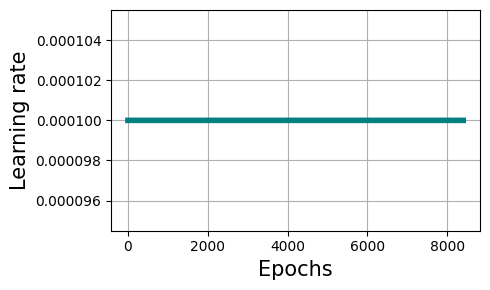

In [18]:
# Print and Plot learning rate
plt.figure(figsize=(5,3))
plt.plot(learning_rates[0:], color = 'teal',linewidth=4)
plt.grid(True)
plt.xlabel('Epochs',fontsize=15)
plt.ylabel('Learning rate',fontsize=15)

plt.tight_layout()

#To save the figure
fig_name = 'learning_rate'
plt.savefig(pinn_output_path+fig_name+'.png', format='png')

plt.show()

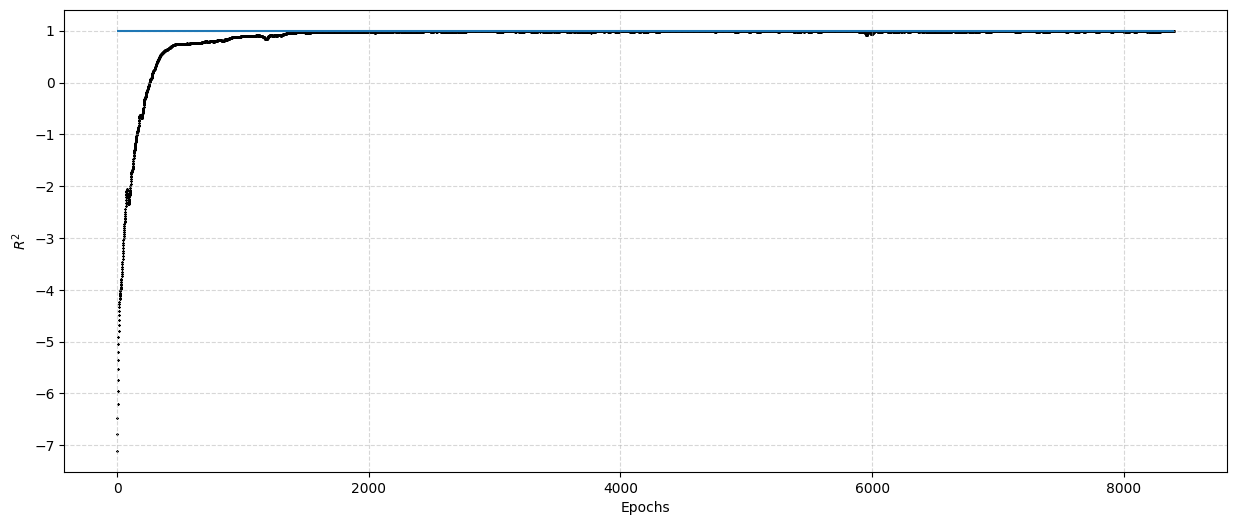

In [19]:
# R2 Epochs
plt.figure(figsize=(15,6))
plt.scatter(range(0,len(r2_score_overall)),r2_score_overall,
            s=1,
            marker="x",
            c="black",
            alpha=1.0)
plt.hlines([1.0],0,epoch_number)
plt.xlabel("Epochs")
plt.ylabel("$R^2$")
plt.title("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Text(0, 0.5, 'Variable fit loss')

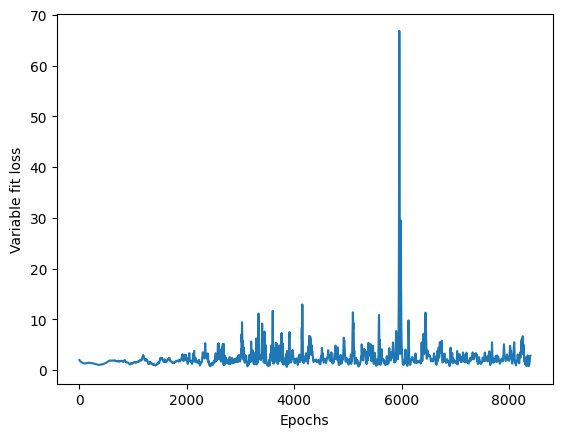

In [20]:
plt.plot(variable_fit_losses)
plt.xlabel("Epochs")
plt.ylabel("Variable fit loss")

Loss:  135.58


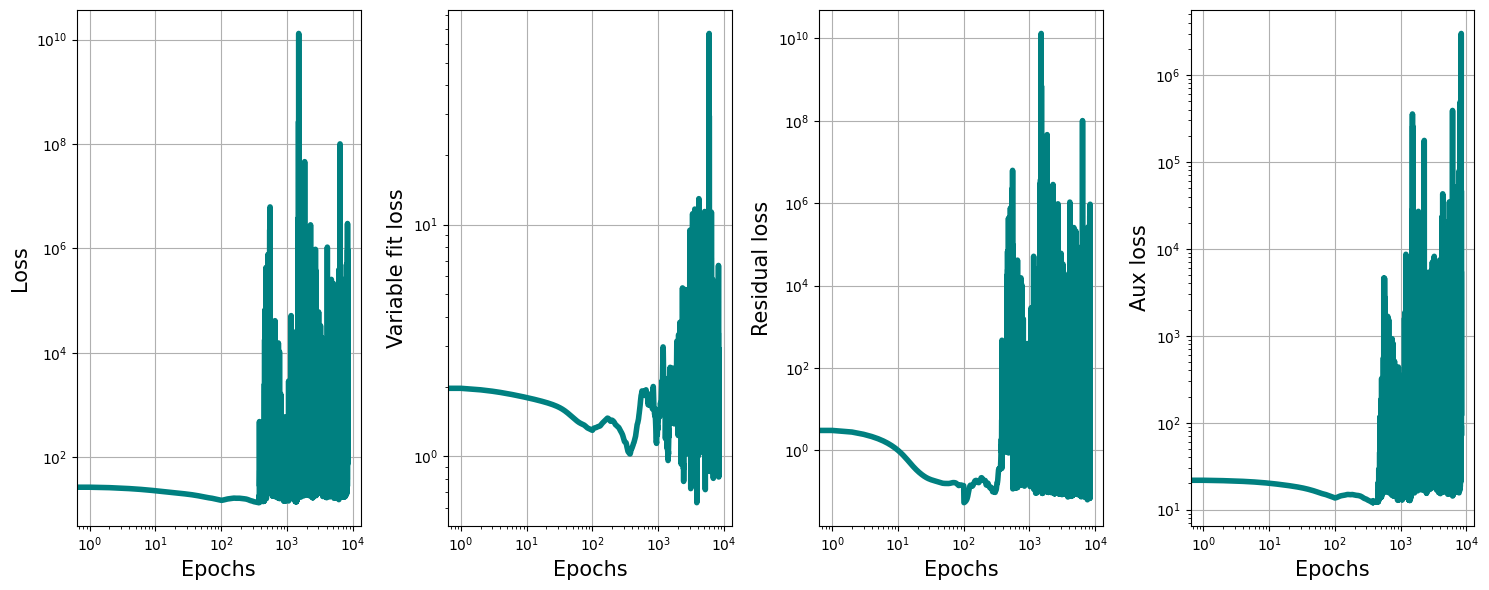

In [21]:
lists_to_plot     = [losses, variable_fit_losses, residual_losses, aux_losses]
lists_to_plot_str = ["Loss", "Variable fit loss", "Residual loss", "Aux loss"]

## Print and Plot Losses
print("Loss: ","%.5g" % losses[-1])
fig, axs = plt.subplots(1, 4, figsize=(15, 6))

for i_plt in range(0,len(lists_to_plot)):
    axs[i_plt].plot(lists_to_plot[i_plt][0:], color = 'teal',linewidth=4)
    axs[i_plt].grid(True)
    axs[i_plt].set_xlabel('Epochs',fontsize=15)
    axs[i_plt].set_ylabel(lists_to_plot_str[i_plt],fontsize=15)
    axs[i_plt].set_xscale('log')
    axs[i_plt].set_yscale('log')

plt.tight_layout()

#To save the figure
fig_name = 'loss_short'
plt.savefig(pinn_output_path+fig_name+'.png', format='png')

plt.show()

r2 : 69.847


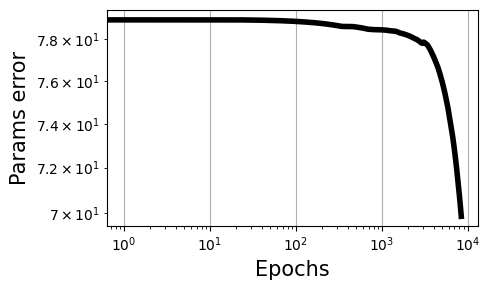

In [22]:
print("r2 :","%.5g" % params_error[-1])

plt.figure(figsize=(5,3))
plt.plot(params_error, color = 'black',linewidth=4)
plt.grid(True)
plt.xlabel('Epochs',fontsize=15)
plt.ylabel('Params error',fontsize=15)
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()

#To save the figure
fig_name = 'error_short'
plt.savefig(pinn_output_path+fig_name+'.png', format='png')

plt.show()

/tmp/ipykernel_55077/3186753471.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(ranges))  # Get a colormap with as many colors as there are ranges


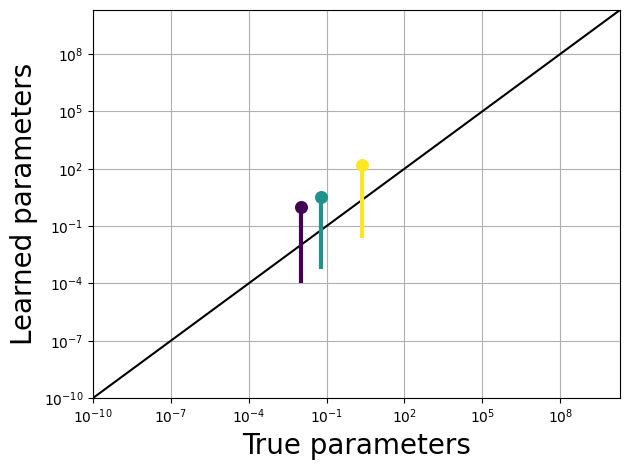

In [23]:
## Comparing parameters
learned_parameters=[pinn_cell.output_param_range(v,i).item() for (i,(k,v)) in enumerate(pinn_cell.ode_parameters.items())]
true_parameters   =[constants_dict[key] for key in prm_to_infer]

plt.grid('true')
plt.plot([0, 2*10**10], [0, 2*10**10],color='black')
plt.scatter(true_parameters,learned_parameters)
plt.xscale('log')
plt.yscale('log')

cmap = plt.cm.get_cmap('viridis', len(ranges))  # Get a colormap with as many colors as there are ranges

# Map each range index to a color from the colormap
colors = [cmap(i) for i in range(len(ranges))]


for i, (true_val, learned_val) in enumerate(zip(true_parameters, learned_parameters)):
    plt.scatter(true_val, learned_val, s=70, color=colors[i], label=f'Range {i}' if i == 0 else "",zorder=3)

    # Also color the corresponding vertical line
    plt.vlines(x=true_val, ymin=ranges[i][0], ymax=ranges[i][1], colors=colors[i],zorder=2,linewidth=3)


min_value = min(r[0] for r in ranges)
max_value = max(r[1] for r in ranges)
plt.ylim([10**(-10),2*10**10])
plt.xlim([10**(-10),2*10**10])

plt.xlabel('True parameters',fontsize=20)
plt.ylabel('Learned parameters',fontsize=20)

plt.tight_layout()

#To save the figure
fig_name = 'params_short'
plt.savefig(pinn_output_path+fig_name+'.png', format='png')

plt.show()

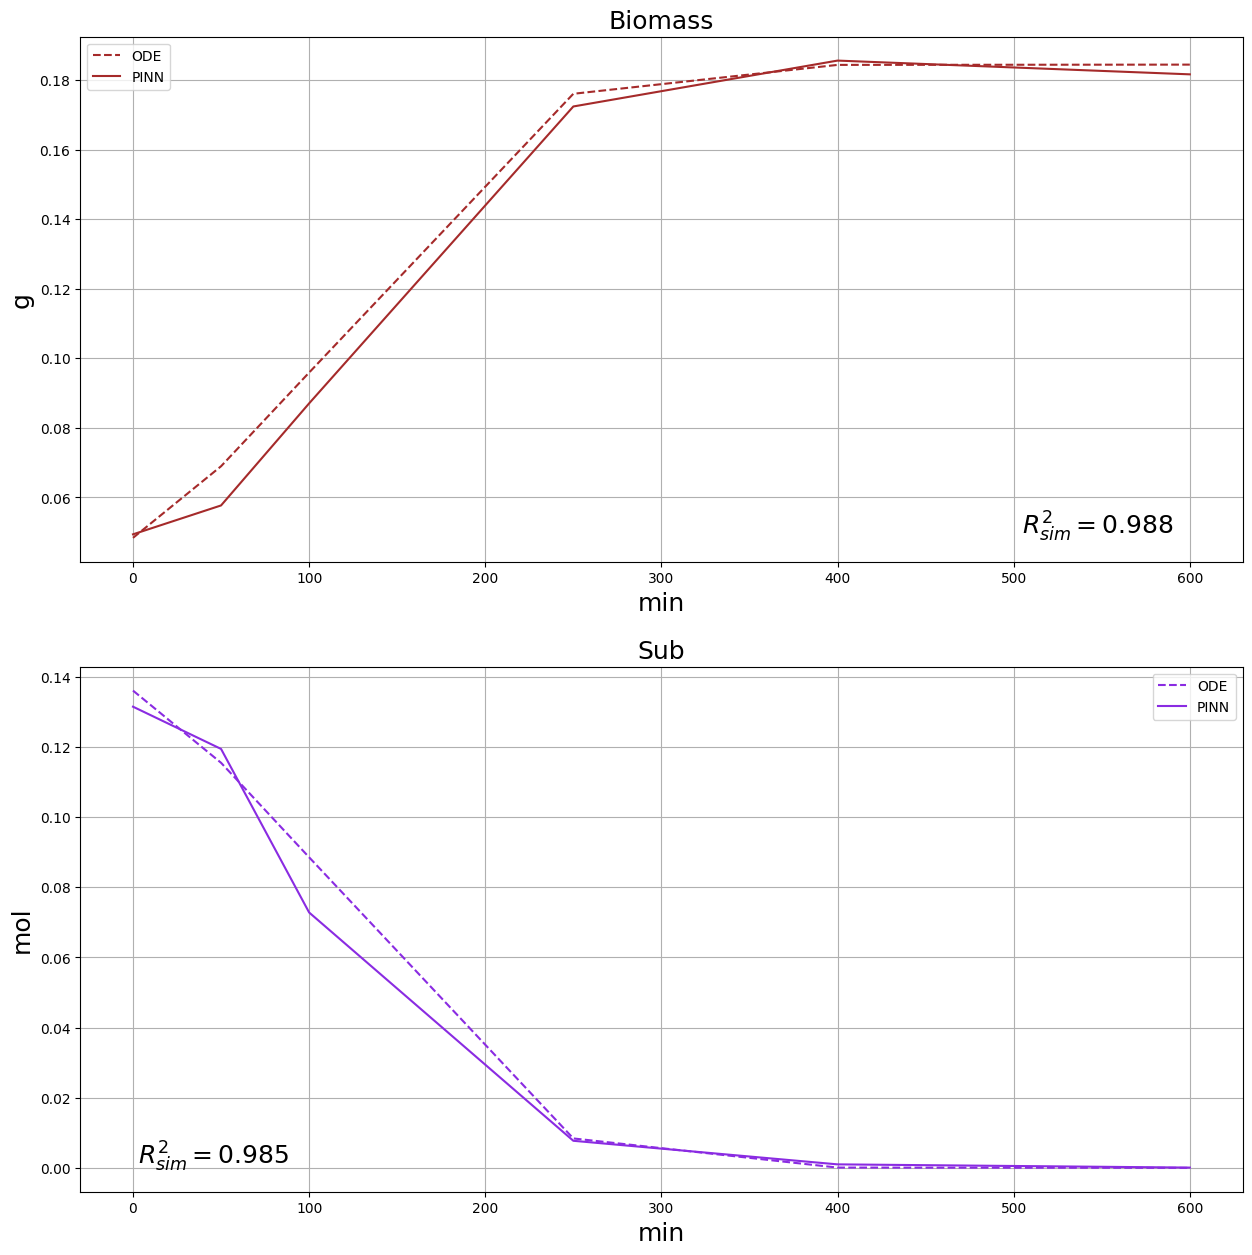

In [32]:
## Plot the predicted variables
fig, (ax0,ax1) = plt.subplots(2, 1, figsize=(15, 15))
fontsize_val   = 18

color_list  = list(mcolors.CSS4_COLORS.keys())
dict_colors = {all_variables[i]: color_list[i+10] for i in range(0,len(all_variables))}

ax0.plot(sol.t, sol.y[name2idx["Biomass"]], linestyle='dashed', label='ODE', color=dict_colors["Biomass"])
ax0.plot(data_t, Biomass_pred.detach().numpy(), label='PINN', color=dict_colors["Biomass"])
#ax0.plot(data_t, variables_data["Biomass"], 'o', label='Data', color=dict_colors["Biomass"])
ax0.text(
    0.81, 0.1, f"$R^2_{{sim}} = {r2_score(sol.y[name2idx['Biomass']],Biomass_pred.detach().numpy()):.3f}$", 
    transform=ax0.transAxes, 
    fontsize=fontsize_val,
    verticalalignment='top',
)
ax0.set_title('Biomass', fontsize = fontsize_val)
ax0.set_xlabel('min', fontsize = fontsize_val)
ax0.set_ylabel(inputs['initials']["Biomass"]["unit"], fontsize = fontsize_val)
ax0.legend()
ax0.grid(True)

ax1.plot(sol.t, sol.y[name2idx["Sub"]], linestyle='dashed', label='ODE', color=dict_colors["Sub"])
ax1.plot(data_t, Sub_pred.detach().numpy(), label='PINN', color=dict_colors["Sub"])
#ax1.plot(data_t, variables_data["Sub"], 'o', label='Data', color=dict_colors["Sub"])
ax1.text(
    0.05, 0.1, f"$R^2_{{sim}} = {r2_score(sol.y[name2idx['Sub']],Sub_pred.detach().numpy()):.3f}$", 
    transform=ax1.transAxes, 
    fontsize=fontsize_val,
    verticalalignment='top',
)
ax1.set_title('Sub', fontsize = fontsize_val)
ax1.set_xlabel('min', fontsize = fontsize_val)
ax1.set_ylabel(inputs['initials']["Sub"]["unit"], fontsize = fontsize_val)
ax1.legend()
ax1.grid(True)

fig_name = f"bioprocess_curvefit_{'_'.join(observables)}"
fig.savefig(pinn_output_path+fig_name+'.png', format='png')

plt.show()